<a href="https://colab.research.google.com/github/PETEROA/ML-Optimization-Daily/blob/main/training_efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Efficiency Analysis

Here, I bring together different efficient training techniques into a comprehensive analysis framework. I profile training pipelines end-to-end, identify bottlenecks (compute, memory, I/O, communication), measure the impact of optimizations (mixed precision, checkpointing, data loading), and build a systematic approach to training efficiency. I implement profilers for GPU utilisation, memory usage, data loading, and communication overhead... create efficiency reports and optimisation recommendations.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torch.cuda.amp import autocast, GradScaler
from torch.utils.checkpoint import checkpoint
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, List, Dict, Tuple, Callable, Any
from dataclasses import dataclass, field
from collections import defaultdict
import time
import gc
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cpu


In [18]:
@dataclass
class EfficiencyMetrics:
    """Container for training efficiency metrics."""

    # Timing
    total_time_s: float = 0.0
    data_load_time_s: float = 0.0
    forward_time_s: float = 0.0
    backward_time_s: float = 0.0
    optimizer_time_s: float = 0.0

    # Memory
    peak_memory_mb: float = 0.0
    avg_memory_mb: float = 0.0
    param_memory_mb: float = 0.0
    activation_memory_mb: float = 0.0

    # Throughput
    samples_per_second: float = 0.0
    batches_per_second: float = 0.0

    # Utilization
    gpu_utilization: float = 0.0
    memory_utilization: float = 0.0

    # Training metrics
    final_loss: float = 0.0
    final_accuracy: float = 0.0

    def compute_derived(self):
        """Compute derived metrics."""
        if self.total_time_s > 0:
            self.data_load_fraction = self.data_load_time_s / self.total_time_s
            self.compute_fraction = (self.forward_time_s + self.backward_time_s) / self.total_time_s
        else:
            self.data_load_fraction = 0
            self.compute_fraction = 0

    def to_dict(self) -> Dict:
        return {
            'total_time_s': self.total_time_s,
            'data_load_time_s': self.data_load_time_s,
            'forward_time_s': self.forward_time_s,
            'backward_time_s': self.backward_time_s,
            'peak_memory_mb': self.peak_memory_mb,
            'samples_per_second': self.samples_per_second,
            'gpu_utilization': self.gpu_utilization,
            'final_loss': self.final_loss,
            'final_accuracy': self.final_accuracy
        }

 GPU Utilization Profiling

In [19]:
class GPUProfiler:
    """
    Profile GPU utilization and performance.

    Tracks:
    - Compute time vs idle time
    - Memory usage over time
    - Kernel execution patterns
    """

    def __init__(self):
        self.compute_times = []
        self.idle_times = []
        self.memory_snapshots = []
        self.timestamps = []
        self._last_time = None
        self._in_compute = False

    def reset(self):
        self.compute_times = []
        self.idle_times = []
        self.memory_snapshots = []
        self.timestamps = []
        self._last_time = None
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()

    def start_compute(self):
        """Mark start of compute phase."""
        if device.type == 'cuda':
            torch.cuda.synchronize()

        now = time.perf_counter()
        if self._last_time is not None and not self._in_compute:
            self.idle_times.append(now - self._last_time)

        self._last_time = now
        self._in_compute = True

    def end_compute(self):
        """Mark end of compute phase."""
        if device.type == 'cuda':
            torch.cuda.synchronize()

        now = time.perf_counter()
        if self._last_time is not None and self._in_compute:
            self.compute_times.append(now - self._last_time)

        self._last_time = now
        self._in_compute = False

        # Snapshot memory
        if device.type == 'cuda':
            self.memory_snapshots.append(torch.cuda.memory_allocated() / 1e6)
            self.timestamps.append(now)

    def get_utilization(self) -> float:
        """Calculate GPU utilization."""
        total_compute = sum(self.compute_times)
        total_idle = sum(self.idle_times)
        total = total_compute + total_idle
        return total_compute / total if total > 0 else 0

    def get_stats(self) -> Dict:
        """Get profiling statistics."""
        return {
            'total_compute_s': sum(self.compute_times),
            'total_idle_s': sum(self.idle_times),
            'utilization': self.get_utilization(),
            'avg_compute_ms': np.mean(self.compute_times) * 1000 if self.compute_times else 0,
            'avg_idle_ms': np.mean(self.idle_times) * 1000 if self.idle_times else 0,
            'peak_memory_mb': max(self.memory_snapshots) if self.memory_snapshots else 0,
            'avg_memory_mb': np.mean(self.memory_snapshots) if self.memory_snapshots else 0
        }

    def plot(self):
        """Visualize GPU profiling results."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Utilization pie chart
        ax = axes[0]
        stats = self.get_stats()
        sizes = [stats['total_compute_s'], stats['total_idle_s']]
        labels = ['Compute', 'Idle']
        colors = ['#2ecc71', '#e74c3c']
        ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        ax.set_title(f"GPU Utilization: {stats['utilization']:.1%}")

        # Memory over time
        ax = axes[1]
        if self.memory_snapshots:
            ax.plot(range(len(self.memory_snapshots)), self.memory_snapshots,
                   linewidth=2, color='steelblue')
            ax.axhline(stats['peak_memory_mb'], color='red', linestyle='--',
                      label=f"Peak: {stats['peak_memory_mb']:.0f}MB")
            ax.axhline(stats['avg_memory_mb'], color='orange', linestyle='--',
                      label=f"Avg: {stats['avg_memory_mb']:.0f}MB")
        ax.set_xlabel('Step')
        ax.set_ylabel('Memory (MB)')
        ax.set_title('GPU Memory Usage')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

GPU Profiling Test

GPU Utilization: 87.2%
Avg compute time: 34.42ms
Avg idle time: 5.14ms
Peak memory: 0MB


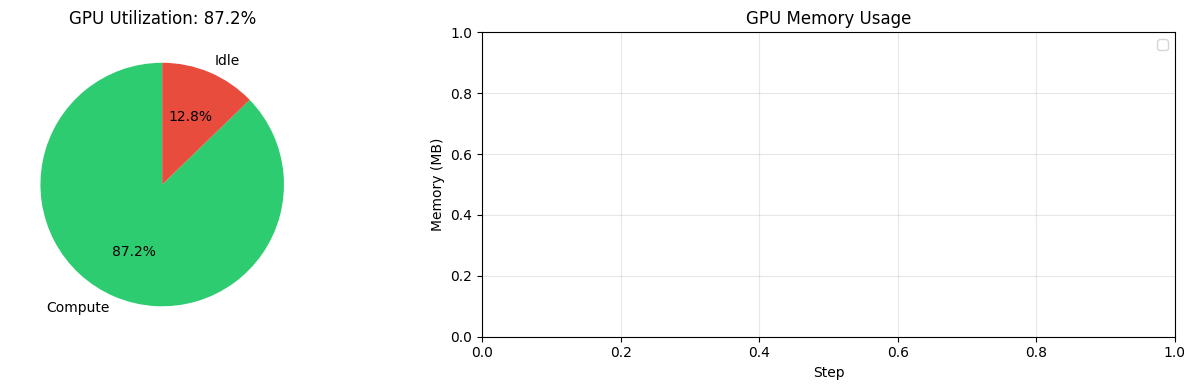

In [20]:
# Test GPU profiler
print("GPU Profiling Test")
print("=" * 50)

profiler = GPUProfiler()
profiler.reset()

# Simulate training steps
model = nn.Sequential(
    nn.Linear(1024, 2048),
    nn.ReLU(),
    nn.Linear(2048, 1024)
).to(device)

for i in range(50):
    # Simulate data loading (idle)
    time.sleep(0.005)  # 5ms

    # Compute phase
    profiler.start_compute()
    x = torch.randn(64, 1024, device=device)
    y = model(x)
    loss = y.sum()
    loss.backward()
    profiler.end_compute()

stats = profiler.get_stats()
print(f"\nGPU Utilization: {stats['utilization']:.1%}")
print(f"Avg compute time: {stats['avg_compute_ms']:.2f}ms")
print(f"Avg idle time: {stats['avg_idle_ms']:.2f}ms")
print(f"Peak memory: {stats['peak_memory_mb']:.0f}MB")

fig = profiler.plot()
plt.savefig('gpu_profile.png', dpi=150, bbox_inches='tight')
plt.show()

Memory Profiling

In [21]:
class MemoryProfiler:
    """
    Detailed memory profiling for training.

    Tracks:
    - Parameter memory
    - Gradient memory
    - Activation memory
    - Optimizer state memory
    """

    def __init__(self, model: nn.Module, optimizer: torch.optim.Optimizer = None):
        self.model = model
        self.optimizer = optimizer
        self.activation_memory = []
        self.hooks = []

    def get_parameter_memory(self) -> float:
        """Get memory used by parameters (MB)."""
        return sum(p.numel() * p.element_size() for p in self.model.parameters()) / 1e6

    def get_gradient_memory(self) -> float:
        """Get memory used by gradients (MB)."""
        total = 0
        for p in self.model.parameters():
            if p.grad is not None:
                total += p.grad.numel() * p.grad.element_size()
        return total / 1e6

    def get_optimizer_memory(self) -> float:
        """Get memory used by optimizer states (MB)."""
        if self.optimizer is None:
            return 0

        total = 0
        for state in self.optimizer.state.values():
            for v in state.values():
                if isinstance(v, torch.Tensor):
                    total += v.numel() * v.element_size()
        return total / 1e6

    def _activation_hook(self, module, input, output):
        """Hook to track activation memory."""
        if isinstance(output, torch.Tensor):
            self.activation_memory.append(output.numel() * output.element_size())

    def profile_forward(self, input_tensor: torch.Tensor) -> Dict:
        """Profile memory during forward pass."""
        self.activation_memory = []

        # Register hooks
        for module in self.model.modules():
            hook = module.register_forward_hook(self._activation_hook)
            self.hooks.append(hook)

        # Forward pass
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()

        with torch.no_grad():
            _ = self.model(input_tensor)

        # Remove hooks
        for hook in self.hooks:
            hook.remove()
        self.hooks = []

        activation_mem = sum(self.activation_memory) / 1e6

        return {
            'parameter_mb': self.get_parameter_memory(),
            'activation_mb': activation_mem,
            'peak_mb': torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0
        }

    def full_memory_report(self, input_tensor: torch.Tensor) -> Dict:
        """Generate full memory report."""
        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        gc.collect()

        # Baseline
        baseline = torch.cuda.memory_allocated() / 1e6 if device.type == 'cuda' else 0

        # Parameters
        param_mem = self.get_parameter_memory()

        # Forward pass
        self.model.train()
        output = self.model(input_tensor)
        forward_mem = torch.cuda.memory_allocated() / 1e6 if device.type == 'cuda' else 0

        # Backward pass
        loss = output.sum()
        loss.backward()
        backward_mem = torch.cuda.memory_allocated() / 1e6 if device.type == 'cuda' else 0
        grad_mem = self.get_gradient_memory()

        # Optimizer step
        if self.optimizer:
            self.optimizer.step()
            self.optimizer.zero_grad()

        optim_mem = self.get_optimizer_memory()
        peak_mem = torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0

        return {
            'baseline_mb': baseline,
            'parameter_mb': param_mem,
            'activation_mb': forward_mem - baseline - param_mem,
            'gradient_mb': grad_mem,
            'optimizer_mb': optim_mem,
            'peak_mb': peak_mem,
            'total_training_mb': param_mem + grad_mem + optim_mem + (forward_mem - baseline - param_mem)
        }

Memory Profiling Test

Memory Breakdown:
  Parameters: 33.6 MB
  Activations: -33.6 MB
  Gradients: 33.6 MB
  Optimizer: 67.2 MB
  Peak: 0.0 MB


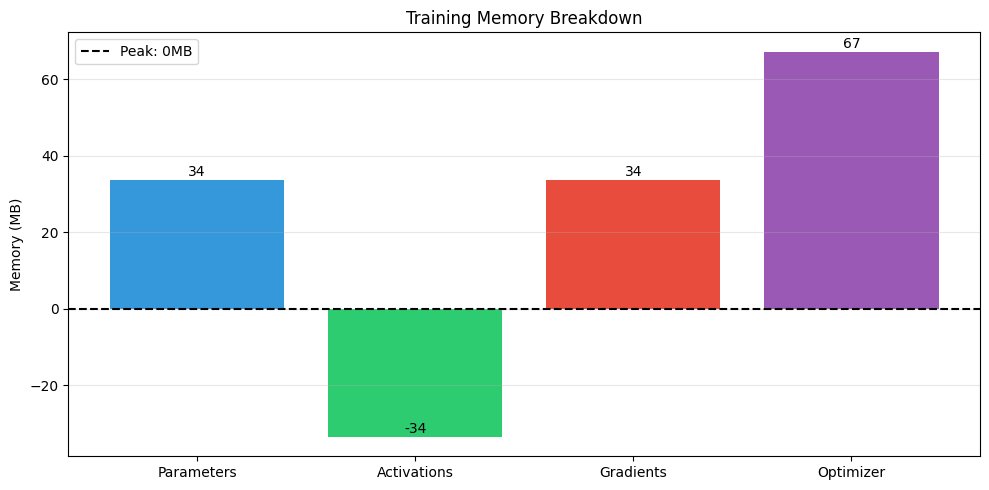

In [22]:
# Test memory profiler
print("Memory Profiling Test")
print("=" * 50)

class TestModel(nn.Module):
    def __init__(self, hidden=1024, layers=8):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(hidden, hidden) for _ in range(layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return x

model = TestModel(hidden=1024, layers=8).to(device)
optimizer = torch.optim.Adam(model.parameters())
profiler = MemoryProfiler(model, optimizer)

x = torch.randn(64, 1024, device=device)
report = profiler.full_memory_report(x)

print(f"\nMemory Breakdown:")
print(f"  Parameters: {report['parameter_mb']:.1f} MB")
print(f"  Activations: {report['activation_mb']:.1f} MB")
print(f"  Gradients: {report['gradient_mb']:.1f} MB")
print(f"  Optimizer: {report['optimizer_mb']:.1f} MB")
print(f"  Peak: {report['peak_mb']:.1f} MB")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
categories = ['Parameters', 'Activations', 'Gradients', 'Optimizer']
values = [report['parameter_mb'], report['activation_mb'],
          report['gradient_mb'], report['optimizer_mb']]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

bars = ax.bar(categories, values, color=colors)
ax.axhline(report['peak_mb'], color='black', linestyle='--',
           label=f"Peak: {report['peak_mb']:.0f}MB")
ax.set_ylabel('Memory (MB)')
ax.set_title('Training Memory Breakdown')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}', ha='center')

plt.tight_layout()
plt.savefig('memory_profile.png', dpi=150, bbox_inches='tight')
plt.show()

Data Loading Analysis

In [23]:
class DataLoadingProfiler:
    """
    Profile data loading performance.
    """

    def __init__(self, dataloader: DataLoader):
        self.dataloader = dataloader
        self.load_times = []
        self.transfer_times = []
        self.batch_sizes = []

    def profile(self, num_batches: int = 50, device: torch.device = None) -> Dict:
        """Profile data loading."""
        self.load_times = []
        self.transfer_times = []
        self.batch_sizes = []

        data_iter = iter(self.dataloader)

        for i in range(num_batches):
            # Data loading
            t0 = time.perf_counter()
            try:
                batch = next(data_iter)
            except StopIteration:
                break
            t1 = time.perf_counter()
            self.load_times.append(t1 - t0)

            # Transfer to device
            if device is not None:
                t2 = time.perf_counter()
                if isinstance(batch, (list, tuple)):
                    _ = [b.to(device) for b in batch if isinstance(b, torch.Tensor)]
                else:
                    _ = batch.to(device)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t3 = time.perf_counter()
                self.transfer_times.append(t3 - t2)

            if isinstance(batch, (list, tuple)):
                self.batch_sizes.append(batch[0].shape[0])
            else:
                self.batch_sizes.append(batch.shape[0])

        return self.get_stats()

    def get_stats(self) -> Dict:
        total_samples = sum(self.batch_sizes)
        total_load_time = sum(self.load_times)
        total_transfer_time = sum(self.transfer_times) if self.transfer_times else 0

        return {
            'num_batches': len(self.load_times),
            'total_samples': total_samples,
            'load_time_s': total_load_time,
            'transfer_time_s': total_transfer_time,
            'avg_load_ms': np.mean(self.load_times) * 1000 if self.load_times else 0,
            'avg_transfer_ms': np.mean(self.transfer_times) * 1000 if self.transfer_times else 0,
            'throughput': total_samples / (total_load_time + total_transfer_time) if total_load_time > 0 else 0,
            'load_std_ms': np.std(self.load_times) * 1000 if self.load_times else 0
        }

    def plot(self):
        """Visualize data loading profile."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Time per batch
        ax = axes[0]
        x = range(len(self.load_times))
        ax.bar(x, [t * 1000 for t in self.load_times], alpha=0.7, label='Load')
        if self.transfer_times:
            ax.bar(x, [t * 1000 for t in self.transfer_times],
                   bottom=[t * 1000 for t in self.load_times], alpha=0.7, label='Transfer')
        ax.set_xlabel('Batch')
        ax.set_ylabel('Time (ms)')
        ax.set_title('Data Loading Time per Batch')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Distribution
        ax = axes[1]
        ax.hist([t * 1000 for t in self.load_times], bins=20, alpha=0.7, label='Load')
        if self.transfer_times:
            ax.hist([t * 1000 for t in self.transfer_times], bins=20, alpha=0.7, label='Transfer')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Count')
        ax.set_title('Time Distribution')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

In [24]:
# Test data loading profiler
print("Data Loading Profile")
print("=" * 50)

# Create dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
subset = Subset(dataset, range(5000))

# Profile with different configurations
configs = [
    {'num_workers': 0, 'pin_memory': False},
    {'num_workers': 2, 'pin_memory': False},
    {'num_workers': 2, 'pin_memory': True},
]

print(f"\n{'Config':<35} {'Load (ms)':>12} {'Transfer (ms)':>14} {'Throughput':>12}")
print("-" * 75)

for config in configs:
    loader = DataLoader(subset, batch_size=64, shuffle=True, **config)
    profiler = DataLoadingProfiler(loader)
    stats = profiler.profile(num_batches=30, device=device)

    config_str = f"workers={config['num_workers']}, pin={config['pin_memory']}"
    print(f"{config_str:<35} {stats['avg_load_ms']:>11.2f} "
          f"{stats['avg_transfer_ms']:>13.2f} {stats['throughput']:>11.0f}/s")

Data Loading Profile

Config                                 Load (ms)  Transfer (ms)   Throughput
---------------------------------------------------------------------------
workers=0, pin=False                      12.19          0.03        5239/s
workers=2, pin=False                      13.11          0.08        4851/s
workers=2, pin=True                       12.47          0.09        5095/s


Training Loop Profiler

In [25]:
class TrainingProfiler:
    """
    Comprehensive training loop profiler.

    Profiles all phases:
    - Data loading
    - Forward pass
    - Loss computation
    - Backward pass
    - Optimizer step
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.times = defaultdict(list)
        self.memory = defaultdict(list)
        self.losses = []
        self.batch_sizes = []

    def profile_step(self, model, optimizer, criterion, data, target,
                     use_amp=False, scaler=None):
        """Profile a single training step."""
        timings = {}

        # Transfer to device
        t0 = time.perf_counter()
        data, target = data.to(device), target.to(device)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        timings['transfer'] = time.perf_counter() - t0

        # Zero grad
        t0 = time.perf_counter()
        optimizer.zero_grad()
        timings['zero_grad'] = time.perf_counter() - t0

        # Forward
        t0 = time.perf_counter()
        if use_amp:
            with autocast():
                output = model(data)
                loss = criterion(output, target)
        else:
            output = model(data)
            loss = criterion(output, target)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        timings['forward'] = time.perf_counter() - t0

        # Backward
        t0 = time.perf_counter()
        if use_amp and scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        timings['backward'] = time.perf_counter() - t0

        # Optimizer step
        t0 = time.perf_counter()
        if use_amp and scaler:
            scaler.step(optimizer)
            scaler.update()
        else:
            optimizer.step()
        if device.type == 'cuda':
            torch.cuda.synchronize()
        timings['optimizer'] = time.perf_counter() - t0

        # Record
        for key, val in timings.items():
            self.times[key].append(val)
        self.losses.append(loss.item())
        self.batch_sizes.append(data.shape[0])

        if device.type == 'cuda':
            self.memory['allocated'].append(torch.cuda.memory_allocated() / 1e6)
            self.memory['peak'].append(torch.cuda.max_memory_allocated() / 1e6)

        return loss.item()

    def get_metrics(self) -> EfficiencyMetrics:
        """Get efficiency metrics."""
        metrics = EfficiencyMetrics()

        metrics.forward_time_s = sum(self.times['forward'])
        metrics.backward_time_s = sum(self.times['backward'])
        metrics.optimizer_time_s = sum(self.times['optimizer'])
        metrics.data_load_time_s = sum(self.times['transfer'])
        metrics.total_time_s = sum(sum(v) for v in self.times.values())

        if self.memory['peak']:
            metrics.peak_memory_mb = max(self.memory['peak'])
            metrics.avg_memory_mb = np.mean(self.memory['allocated'])

        total_samples = sum(self.batch_sizes)
        if metrics.total_time_s > 0:
            metrics.samples_per_second = total_samples / metrics.total_time_s
            metrics.batches_per_second = len(self.batch_sizes) / metrics.total_time_s

        metrics.final_loss = self.losses[-1] if self.losses else 0
        metrics.compute_derived()

        return metrics

    def get_breakdown(self) -> Dict:
        """Get time breakdown."""
        total = sum(sum(v) for v in self.times.values())
        breakdown = {}
        for key, vals in self.times.items():
            t = sum(vals)
            breakdown[key] = {
                'total_s': t,
                'avg_ms': np.mean(vals) * 1000,
                'fraction': t / total if total > 0 else 0
            }
        return breakdown

    def plot(self):
        """Visualize profiling results."""
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        breakdown = self.get_breakdown()

        # Time breakdown pie chart
        ax = axes[0, 0]
        labels = list(breakdown.keys())
        sizes = [breakdown[k]['total_s'] for k in labels]
        colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
        ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
        ax.set_title('Time Breakdown')

        # Time per step
        ax = axes[0, 1]
        steps = range(len(self.times['forward']))
        bottom = np.zeros(len(steps))
        for key in ['transfer', 'forward', 'backward', 'optimizer']:
            if key in self.times:
                vals = [v * 1000 for v in self.times[key]]
                ax.bar(steps, vals, bottom=bottom, label=key, alpha=0.8)
                bottom += np.array(vals)
        ax.set_xlabel('Step')
        ax.set_ylabel('Time (ms)')
        ax.set_title('Time per Step')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Loss curve
        ax = axes[1, 0]
        ax.plot(self.losses, linewidth=2)
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        ax.set_title('Training Loss')
        ax.grid(True, alpha=0.3)

        # Memory usage
        ax = axes[1, 1]
        if self.memory['allocated']:
            ax.plot(self.memory['allocated'], label='Allocated', linewidth=2)
            ax.plot(self.memory['peak'], label='Peak', linewidth=2, linestyle='--')
            ax.set_xlabel('Step')
            ax.set_ylabel('Memory (MB)')
            ax.set_title('GPU Memory')
            ax.legend()
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig

Training Loop Profiling

Efficiency Metrics:
  Throughput: 628 samples/s
  Peak memory: 0 MB
  Final loss: 0.3141

Time Breakdown:
  transfer: 0.10ms (0.1%)
  zero_grad: 0.29ms (0.3%)
  forward: 55.18ms (54.2%)
  backward: 44.98ms (44.2%)
  optimizer: 1.31ms (1.3%)


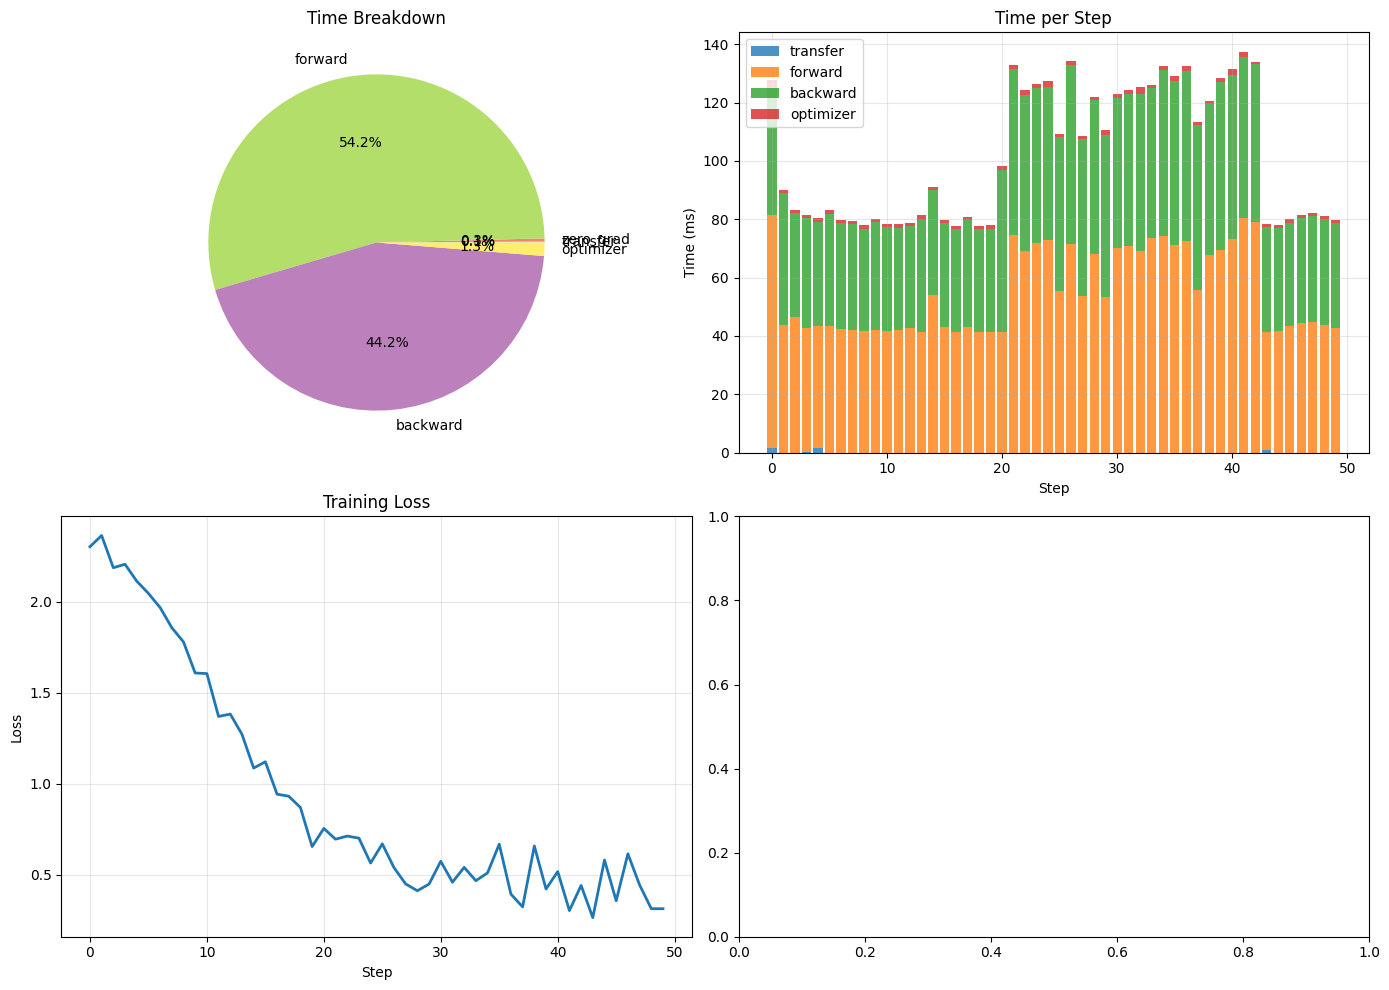

In [26]:
# Test training profiler
print("Training Loop Profiling")
print("=" * 50)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d(7)
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

loader = DataLoader(subset, batch_size=64, shuffle=True, num_workers=2)

profiler = TrainingProfiler()

model.train()
for i, (data, target) in enumerate(loader):
    if i >= 50:
        break
    profiler.profile_step(model, optimizer, criterion, data, target)

metrics = profiler.get_metrics()
breakdown = profiler.get_breakdown()

print(f"\nEfficiency Metrics:")
print(f"  Throughput: {metrics.samples_per_second:.0f} samples/s")
print(f"  Peak memory: {metrics.peak_memory_mb:.0f} MB")
print(f"  Final loss: {metrics.final_loss:.4f}")

print(f"\nTime Breakdown:")
for phase, stats in breakdown.items():
    print(f"  {phase}: {stats['avg_ms']:.2f}ms ({stats['fraction']:.1%})")

fig = profiler.plot()
plt.savefig('training_profile.png', dpi=150, bbox_inches='tight')
plt.show()

Optimization Impact Analysis

In [27]:
class OptimizationAnalyzer:
    """
    Analyze impact of different optimizations.
    """

    def __init__(self, model_fn: Callable, dataloader: DataLoader):
        self.model_fn = model_fn
        self.dataloader = dataloader
        self.results = {}

    def benchmark_config(self, name: str, use_amp: bool = False,
                         use_checkpoint: bool = False, num_steps: int = 30) -> Dict:
        """Benchmark a specific configuration."""
        model = self.model_fn().to(device)
        optimizer = torch.optim.Adam(model.parameters())
        criterion = nn.CrossEntropyLoss()
        scaler = GradScaler() if use_amp else None

        if device.type == 'cuda':
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.empty_cache()
        gc.collect()

        profiler = TrainingProfiler()
        model.train()

        data_iter = iter(self.dataloader)
        for i in range(num_steps):
            try:
                data, target = next(data_iter)
            except StopIteration:
                data_iter = iter(self.dataloader)
                data, target = next(data_iter)

            profiler.profile_step(model, optimizer, criterion, data, target,
                                 use_amp=use_amp, scaler=scaler)

        metrics = profiler.get_metrics()

        result = {
            'name': name,
            'throughput': metrics.samples_per_second,
            'peak_memory_mb': metrics.peak_memory_mb,
            'avg_step_ms': metrics.total_time_s / num_steps * 1000,
            'final_loss': metrics.final_loss
        }

        self.results[name] = result
        return result

    def run_comparison(self) -> Dict:
        """Run full comparison of optimizations."""
        print("Running optimization comparison...")

        # Baseline
        print("  Baseline (FP32)...")
        self.benchmark_config('Baseline', use_amp=False)

        # Mixed precision
        if device.type == 'cuda':
            print("  Mixed Precision (AMP)...")
            self.benchmark_config('AMP', use_amp=True)

        return self.results

    def plot_comparison(self):
        """Plot comparison results."""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        names = list(self.results.keys())
        colors = plt.cm.Set2(np.linspace(0, 1, len(names)))

        # Throughput
        ax = axes[0]
        throughputs = [self.results[n]['throughput'] for n in names]
        bars = ax.bar(names, throughputs, color=colors)
        ax.set_ylabel('Samples/second')
        ax.set_title('Throughput')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, throughputs):
            ax.text(bar.get_x() + bar.get_width()/2, val + max(throughputs)*0.02,
                   f'{val:.0f}', ha='center')

        # Memory
        ax = axes[1]
        memories = [self.results[n]['peak_memory_mb'] for n in names]
        bars = ax.bar(names, memories, color=colors)
        ax.set_ylabel('Peak Memory (MB)')
        ax.set_title('Memory Usage')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, memories):
            ax.text(bar.get_x() + bar.get_width()/2, val + max(memories)*0.02,
                   f'{val:.0f}', ha='center')

        # Step time
        ax = axes[2]
        times = [self.results[n]['avg_step_ms'] for n in names]
        bars = ax.bar(names, times, color=colors)
        ax.set_ylabel('Step Time (ms)')
        ax.set_title('Training Speed')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, times):
            ax.text(bar.get_x() + bar.get_width()/2, val + max(times)*0.02,
                   f'{val:.1f}', ha='center')

        plt.tight_layout()
        return fig

Optimization Impact Analysis
Running optimization comparison...
  Baseline (FP32)...

Config            Throughput  Memory (MB)    Step (ms)
-------------------------------------------------------
Baseline                767           0        83.5


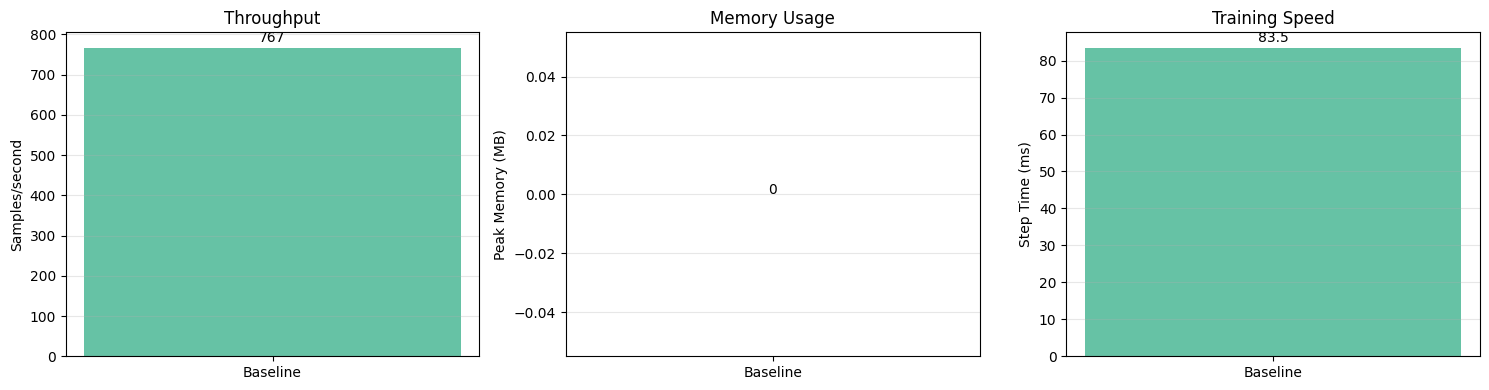

In [28]:
# Test optimization analyzer
print("Optimization Impact Analysis")
print("=" * 50)

analyzer = OptimizationAnalyzer(CNN, loader)
results = analyzer.run_comparison()

print(f"\n{'Config':<15} {'Throughput':>12} {'Memory (MB)':>12} {'Step (ms)':>12}")
print("-" * 55)
for name, res in results.items():
    print(f"{name:<15} {res['throughput']:>11.0f} {res['peak_memory_mb']:>11.0f} "
          f"{res['avg_step_ms']:>11.1f}")

fig = analyzer.plot_comparison()
plt.savefig('optimization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Bottleneck Detection

In [29]:
class BottleneckDetector:
    """
    Detect training bottlenecks and provide recommendations.
    """

    def __init__(self):
        self.analysis = {}
        self.recommendations = []

    def analyze(self, training_profiler: TrainingProfiler,
                data_profiler: DataLoadingProfiler = None,
                memory_report: Dict = None) -> Dict:
        """Analyze for bottlenecks."""
        self.recommendations = []

        breakdown = training_profiler.get_breakdown()
        metrics = training_profiler.get_metrics()

        # Analyze time breakdown
        self.analysis['time_breakdown'] = breakdown

        # Check for data loading bottleneck
        data_fraction = breakdown.get('transfer', {}).get('fraction', 0)
        if data_fraction > 0.3:
            self.recommendations.append({
                'type': 'DATA_LOADING',
                'severity': 'HIGH' if data_fraction > 0.5 else 'MEDIUM',
                'message': f'Data loading takes {data_fraction:.1%} of training time',
                'suggestions': [
                    'Increase num_workers in DataLoader',
                    'Enable pin_memory=True',
                    'Use prefetching',
                    'Pre-process and cache data'
                ]
            })

        # Check for memory bottleneck
        if memory_report:
            activation_ratio = memory_report.get('activation_mb', 0) / max(memory_report.get('peak_mb', 1), 1)
            if activation_ratio > 0.5:
                self.recommendations.append({
                    'type': 'MEMORY',
                    'severity': 'HIGH' if activation_ratio > 0.7 else 'MEDIUM',
                    'message': f'Activations use {activation_ratio:.1%} of peak memory',
                    'suggestions': [
                        'Use gradient checkpointing',
                        'Reduce batch size',
                        'Use mixed precision (FP16)',
                        'Enable activation compression'
                    ]
                })

        # Check GPU utilization
        compute_fraction = breakdown.get('forward', {}).get('fraction', 0) + \
                          breakdown.get('backward', {}).get('fraction', 0)
        if compute_fraction < 0.7:
            self.recommendations.append({
                'type': 'GPU_UTILIZATION',
                'severity': 'MEDIUM' if compute_fraction > 0.5 else 'HIGH',
                'message': f'GPU compute is only {compute_fraction:.1%} of time',
                'suggestions': [
                    'Increase batch size',
                    'Optimize data loading',
                    'Use CUDA graphs for small batches',
                    'Check for CPU-bound operations'
                ]
            })

        # Check optimizer overhead
        optimizer_fraction = breakdown.get('optimizer', {}).get('fraction', 0)
        if optimizer_fraction > 0.2:
            self.recommendations.append({
                'type': 'OPTIMIZER',
                'severity': 'LOW',
                'message': f'Optimizer step takes {optimizer_fraction:.1%} of time',
                'suggestions': [
                    'Consider using SGD instead of Adam',
                    'Use fused optimizers if available',
                    'Increase batch size to amortize overhead'
                ]
            })

        self.analysis['recommendations'] = self.recommendations
        return self.analysis

    def print_report(self):
        """Print bottleneck analysis report."""
        print("\n" + "=" * 60)
        print("BOTTLENECK ANALYSIS REPORT")
        print("=" * 60)

        if not self.recommendations:
            print("\n✓ No significant bottlenecks detected!")
            return

        for rec in self.recommendations:
            severity_icon = {'HIGH': '🔴', 'MEDIUM': '🟡', 'LOW': '🟢'}[rec['severity']]
            print(f"\n{severity_icon} [{rec['type']}] {rec['message']}")
            print("  Suggestions:")
            for sug in rec['suggestions']:
                print(f"    • {sug}")

In [30]:
# Test bottleneck detector
print("Bottleneck Detection")
print("=" * 50)

# Get memory report
model = CNN().to(device)
optimizer = torch.optim.Adam(model.parameters())
mem_profiler = MemoryProfiler(model, optimizer)
x = torch.randn(64, 1, 28, 28, device=device)
memory_report = mem_profiler.full_memory_report(x)

# Run bottleneck analysis
detector = BottleneckDetector()
analysis = detector.analyze(profiler, memory_report=memory_report)
detector.print_report()

Bottleneck Detection

BOTTLENECK ANALYSIS REPORT

✓ No significant bottlenecks detected!


Efficiency Report Generator

In [31]:
class EfficiencyReportGenerator:
    """
    Generate comprehensive training efficiency report.
    """

    def __init__(self, model: nn.Module, dataloader: DataLoader):
        self.model = model
        self.dataloader = dataloader
        self.report_data = {}

    def generate_report(self, num_steps: int = 50) -> str:
        """Generate full efficiency report."""
        # Profile training
        optimizer = torch.optim.Adam(self.model.parameters())
        criterion = nn.CrossEntropyLoss()

        training_profiler = TrainingProfiler()
        self.model.train()

        data_iter = iter(self.dataloader)
        for i in range(num_steps):
            try:
                data, target = next(data_iter)
            except StopIteration:
                data_iter = iter(self.dataloader)
                data, target = next(data_iter)
            training_profiler.profile_step(self.model, optimizer, criterion, data, target)

        metrics = training_profiler.get_metrics()
        breakdown = training_profiler.get_breakdown()

        # Memory analysis
        mem_profiler = MemoryProfiler(self.model, optimizer)
        sample_batch = next(iter(self.dataloader))[0].to(device)
        memory_report = mem_profiler.full_memory_report(sample_batch)

        # Bottleneck analysis
        detector = BottleneckDetector()
        detector.analyze(training_profiler, memory_report=memory_report)

        # Generate report
        report = []
        report.append("=" * 70)
        report.append("           TRAINING EFFICIENCY REPORT")
        report.append("=" * 70)

        # Model info
        total_params = sum(p.numel() for p in self.model.parameters())
        report.append(f"\n[MODEL INFORMATION]")
        report.append(f"  Parameters: {total_params:,}")
        report.append(f"  Parameter memory: {memory_report['parameter_mb']:.1f} MB")

        # Performance
        report.append(f"\n[PERFORMANCE METRICS]")
        report.append(f"  Throughput: {metrics.samples_per_second:.0f} samples/s")
        report.append(f"  Batches/second: {metrics.batches_per_second:.1f}")
        report.append(f"  Avg step time: {metrics.total_time_s / num_steps * 1000:.2f} ms")

        # Time breakdown
        report.append(f"\n[TIME BREAKDOWN]")
        for phase, stats in breakdown.items():
            report.append(f"  {phase}: {stats['avg_ms']:.2f} ms ({stats['fraction']:.1%})")

        # Memory
        report.append(f"\n[MEMORY ANALYSIS]")
        report.append(f"  Peak memory: {metrics.peak_memory_mb:.0f} MB")
        report.append(f"  Parameters: {memory_report['parameter_mb']:.1f} MB")
        report.append(f"  Activations: {memory_report['activation_mb']:.1f} MB")
        report.append(f"  Gradients: {memory_report['gradient_mb']:.1f} MB")
        report.append(f"  Optimizer: {memory_report['optimizer_mb']:.1f} MB")

        # Recommendations
        report.append(f"\n[RECOMMENDATIONS]")
        if detector.recommendations:
            for rec in detector.recommendations:
                severity = {'HIGH': '!!!', 'MEDIUM': '!!', 'LOW': '!'}[rec['severity']]
                report.append(f"  {severity} {rec['message']}")
                for sug in rec['suggestions'][:2]:
                    report.append(f"      → {sug}")
        else:
            report.append("  ✓ No significant bottlenecks detected")

        report.append("\n" + "=" * 70)

        return "\n".join(report)

    def save_report(self, filepath: str, num_steps: int = 50):
        """Save report to file."""
        report = self.generate_report(num_steps)
        with open(filepath, 'w') as f:
            f.write(report)
        return report

In [32]:
# Generate efficiency report
print("Generating Efficiency Report...")

model = CNN().to(device)
generator = EfficiencyReportGenerator(model, loader)
report = generator.generate_report(num_steps=30)
print(report)

Generating Efficiency Report...
           TRAINING EFFICIENCY REPORT

[MODEL INFORMATION]
  Parameters: 50,186
  Parameter memory: 0.2 MB

[PERFORMANCE METRICS]
  Throughput: 775 samples/s
  Batches/second: 12.1
  Avg step time: 82.61 ms

[TIME BREAKDOWN]
  transfer: 0.04 ms (0.1%)
  zero_grad: 0.15 ms (0.2%)
  forward: 44.83 ms (54.3%)
  backward: 36.48 ms (44.2%)
  optimizer: 1.11 ms (1.3%)

[MEMORY ANALYSIS]
  Peak memory: 0 MB
  Parameters: 0.2 MB
  Activations: -0.2 MB
  Gradients: 0.2 MB
  Optimizer: 0.4 MB

[RECOMMENDATIONS]
  ✓ No significant bottlenecks detected

